### Naseem Saleh
### INST414
### Module 1 Assignment
### September 19, 2025

Warning:
This dataset was collected during a specific period of time. Therefore, it cannot be used to generalize pet adoption behavior.


Dataset Usage and Attribution Notice
This dataset, shared by Rabie El Kharoua, is original and has never been shared before. It is made available under the CC BY 4.0 license

@misc{rabie_el_kharoua_2024,
	title={🐾 Predict Pet Adoption Status Dataset 🐾},
	url={https://www.kaggle.com/ds/5242440},
	DOI={10.34740/KAGGLE/DS/5242440},
	publisher={Kaggle},
	author={Rabie El kharoua},
	year={2024}
}

Rabie El kharoua. (2024). 🐾 Predict Pet Adoption Status Dataset 🐾 [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DS/5242440

Exclusive Synthetic Dataset


- Question: What cats are less popular, less likely to be adopted, or usually have longer times in shelter?

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Loads the data sets into Pandas dataframes
pet_adoption_df = pd.read_csv("pet_adoption_data.csv")

# Prints the first few rows of the data sets to make sure it's fine
print("Pet Adoption Data:")       
pet_adoption_df.head()

Pet Adoption Data:


,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0


In [48]:
#Filtering to get only cats:
cats_df = pet_adoption_df[pet_adoption_df["PetType"] == "Cat"].copy()
#Checking the data
cats_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1


In [49]:
cats_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 7 to 2000
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               505 non-null    int64  
 1   PetType             505 non-null    object 
 2   Breed               505 non-null    object 
 3   AgeMonths           505 non-null    int64  
 4   Color               505 non-null    object 
 5   Size                505 non-null    object 
 6   WeightKg            505 non-null    float64
 7   Vaccinated          505 non-null    int64  
 8   HealthCondition     505 non-null    int64  
 9   TimeInShelterDays   505 non-null    int64  
 10  AdoptionFee         505 non-null    int64  
 11  PreviousOwner       505 non-null    int64  
 12  AdoptionLikelihood  505 non-null    int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 55.2+ KB


In [50]:
cats_df.describe()

,PetID,AgeMonths,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,1503.869307,91.376238,15.647825,0.697030,0.219802,42.932673,247.263366,0.324752,0.287129
std,578.428727,52.524229,8.501580,0.459998,0.414523,26.082352,143.107061,0.468747,0.452871
min,507.000000,2.000000,1.018198,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,987.000000,49.000000,8.628049,0.000000,0.000000,18.000000,128.000000,0.000000,0.000000
50%,1508.000000,89.000000,15.687235,1.000000,0.000000,44.000000,238.000000,0.000000,0.000000
75%,2008.000000,138.000000,22.924123,1.000000,0.000000,65.000000,367.000000,1.000000,1.000000
max,2500.000000,179.000000,29.992795,1.000000,1.000000,89.000000,499.000000,1.000000,1.000000


In [52]:

#Checking how many cats there are by color:
cats_df["Color"].value_counts()

Color
Black     114
Orange    108
White     100
Brown      97
Gray       86
Name: count, dtype: int64

In [163]:
#Turning the age from months to years to be a bit more meaningful, keeping younger than 1 without rounding:
cats_df["AgeYears"] = np.floor(cats_df['AgeMonths'] / 12)
#Print to check:
cats_df.head()

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood,AgeYears,TimeInShelterMonths
7,507,Cat,Siamese,13,Orange,Large,7.252683,1,0,3,137,0,1,1.0,0.0
13,513,Cat,Siamese,27,Black,Large,28.285412,1,0,5,135,0,0,2.0,0.0
14,514,Cat,Persian,160,Brown,Medium,6.303899,1,0,11,404,0,1,13.0,0.0
16,516,Cat,Persian,8,Orange,Small,11.933224,1,1,64,405,1,0,0.0,2.0
17,517,Cat,Persian,50,White,Medium,28.982929,1,0,13,109,0,1,4.0,0.0


In [61]:
#Filtering by black cats older than or equal to six years
#older_black_cats_df = cats_df[(cats_df["Color"] == "Black") & (cats_df["AgeYears"] >= 6)] 


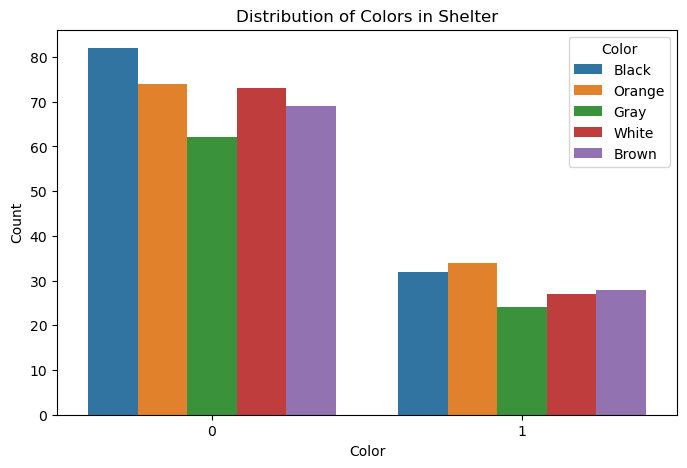

In [113]:
# Create a count bar plot for how many cats of a certain color are in the shelter:
plt.figure(figsize=(8, 5))
sns.countplot(x = "AdoptionLikelihood", data = cats_df, hue = "Color")
plt.xlabel("Not Adopted vs Adopted")
plt.ylabel("Count")
plt.title("Distribution of Colors in Shelter")

# Show the plot:
plt.show()

    PetID PetType    Breed  AgeMonths   Color    Size   WeightKg  Vaccinated  \
7     507     Cat  Siamese         13  Orange   Large   7.252683           1   
13    513     Cat  Siamese         27   Black   Large  28.285412           1   
14    514     Cat  Persian        160   Brown  Medium   6.303899           1   
16    516     Cat  Persian          8  Orange   Small  11.933224           1   
17    517     Cat  Persian         50   White  Medium  28.982929           1   

    HealthCondition  TimeInShelterDays  AdoptionFee  PreviousOwner  \
7                 0                  3          137              0   
13                0                  5          135              0   
14                0                 11          404              0   
16                1                 64          405              1   
17                0                 13          109              0   

    AdoptionLikelihood   AgeYears  TimeInShelterMonths  
7                    1   1.000000        

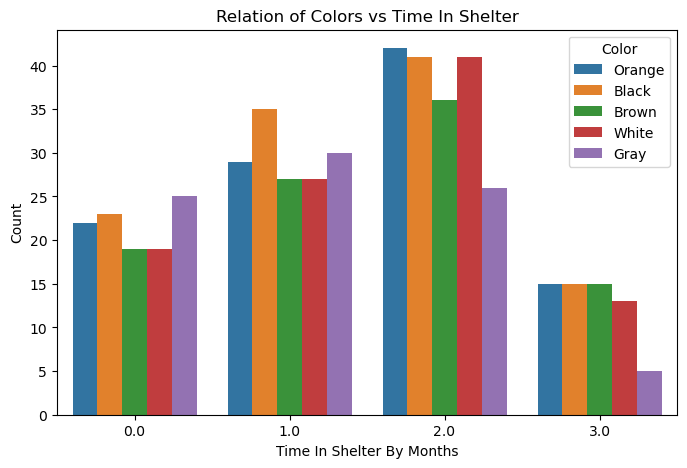

In [158]:
#Rounding the time in shelter to months
cats_df["TimeInShelterMonths"] = (cats_df["TimeInShelterDays"] / 30).round()

print(cats_df.head())
# Create a count bar plot for how many cats of a certain color are in the shelter:
plt.figure(figsize=(8, 5))
sns.countplot(x = "TimeInShelterMonths", data = cats_df, hue = "Color")
plt.xlabel("Time In Shelter By Months")
plt.ylabel("Count")
plt.title("Relation of Colors vs Time In Shelter")

# Show the plot:
plt.show()

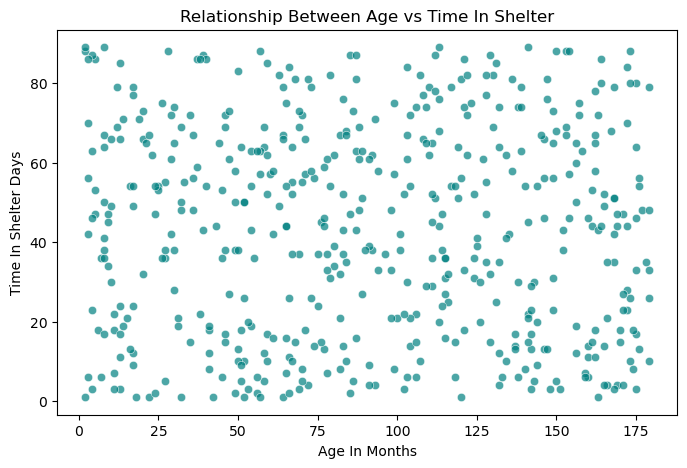

In [160]:
# Creating a scatterplot to see if there is a relationship between Age and time in the shelter
plt.figure(figsize=(8, 5))
sns.scatterplot(x="AgeMonths", y="TimeInShelterDays", color="teal", data = cats_df, alpha = 0.7)
plt.xlabel("Age In Months")
plt.ylabel("Time In Shelter Days")
plt.title("Relationship Between Age vs Time In Shelter")
# Showing the scatter plot:
plt.show()

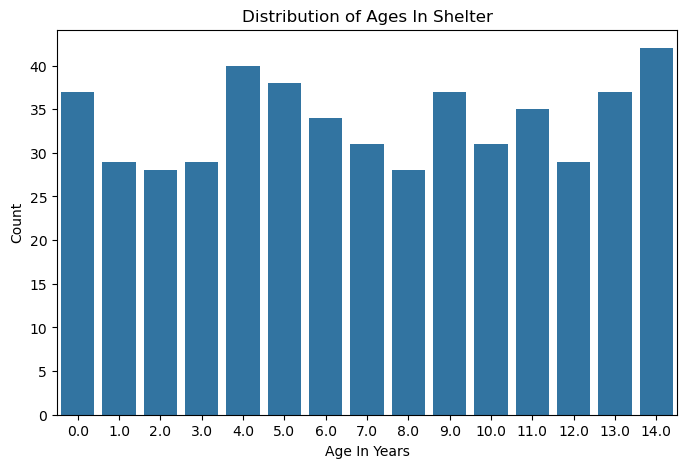

In [165]:
#Counting the ages of cats in shelter
plt.figure(figsize=(8, 5))
sns.countplot(x = "AgeYears", data = cats_df)
plt.xlabel("Age In Years")
plt.ylabel("Count")
plt.title("Distribution of Ages In Shelter")

# Show the plot:
plt.show()

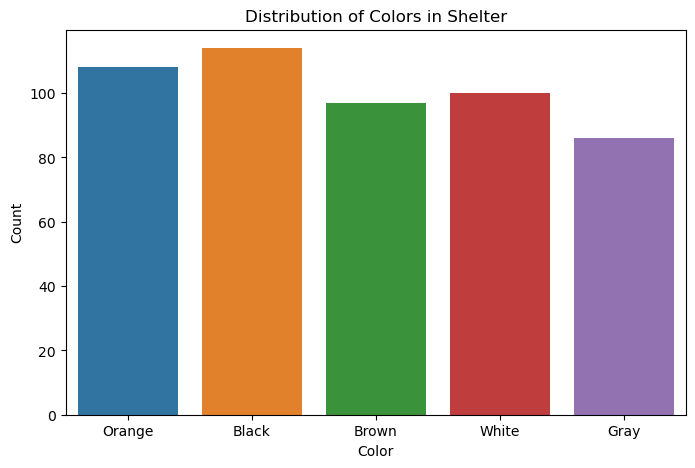

In [82]:
# Create a count bar plot for how many cats of a certain color are in the shelter:
plt.figure(figsize=(8, 5))
sns.countplot(x = "Color", data = cats_df, hue = "Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.title("Distribution of Colors in Shelter")

# Show the plot:
plt.show()

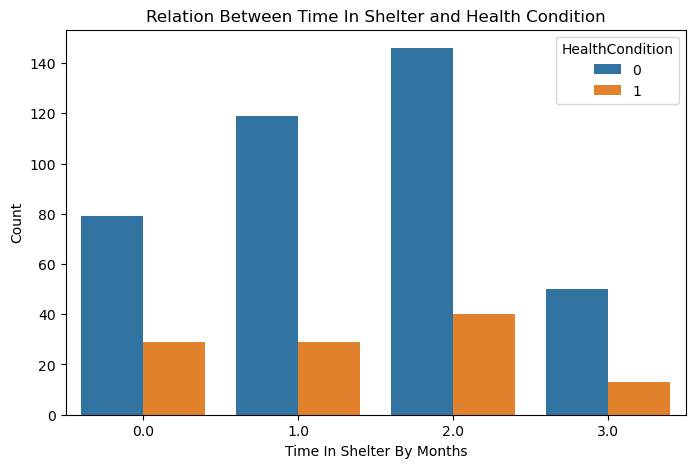

In [157]:
# Looking at if having a health condition correlates with time in shelter:
plt.figure(figsize=(8, 5))
sns.countplot(x = "TimeInShelterMonths", data = cats_df, hue = "HealthCondition")
plt.xlabel("Time In Shelter By Months")
plt.ylabel("Count")
plt.title("Relation Between Time In Shelter and Health Condition")

# Show the plot:
plt.show()

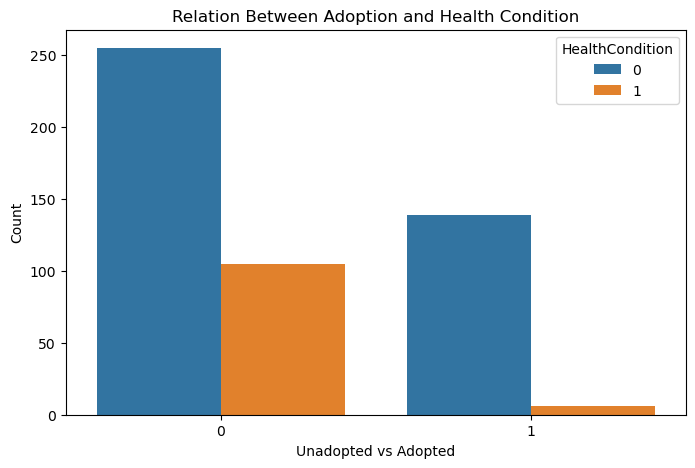

In [152]:
# Looking at if having a health condition correlates with adoption
plt.figure(figsize=(8, 5))
sns.countplot(x = "AdoptionLikelihood", data = cats_df, hue = "HealthCondition")
plt.xlabel("Unadopted vs Adopted")
plt.ylabel("Count")
plt.title("Relation Between Adoption and Health Condition")

# Show the plot:
plt.show()